In [17]:
import pandas as pd
import pickle

from scipy.stats import friedmanchisquare

import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

In [2]:
# Load real dataset results
with open('data_real.pkl', "rb") as f:
    real = pickle.load(f)['kwargs']['df']

# Load synthetic dataset results
with open('data_synthetic.pkl', "rb") as f:
    synth = pickle.load(f)['kwargs']['df']

results_df = pd.concat([real, synth], axis=1)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [3]:
# Calculate the number dataframe index runs level
num_runs = results_df.index.get_level_values('run').nunique()

# Reorder MultiIndex columns for consistent plotting
order = {
    'dataset': [
        '197_cpu_act', '4544_GOM', '505_tecator', 'CCN', 'CCUN',
        'F1', 'F2', 'Friedman1', 'Friedman2', 'Friedman3'
    ],
    'method':  ['GPPI', 'GPSHAP', 'GPCMI', 'RFGPCMI', 'GP'],
    'metric':  ['training_losses', 'validation_losses', 'test_losses']
}

# Define colors for each method
colors = sns.color_palette(n_colors=len(order['method']))
hue = dict(zip(order['method'], colors))

for level, cols in order.items():
    results_df = results_df.reindex(columns=cols, level=level)

results_df.tail(3)

dataset       197_cpu_act                                                \
method               GPPI                                        GPSHAP   
metric    training_losses validation_losses test_losses training_losses   
run epoch                                                                 
99  90           0.085219          0.084149    0.085306        0.045534   
    95           0.084591          0.085717    0.085306        0.044165   
    100          0.085040          0.084600    0.085306        0.044693   

dataset                                                                    \
method                                            GPCMI                     
metric    validation_losses test_losses training_losses validation_losses   
run epoch                                                                   
99  90             0.043935    0.044745        0.110546          0.109176   
    95             0.043669    0.043691        0.109700          0.111288   
    100            0.042306    0.043691        0.111237          0.107406   

dataset                                ...   Friedman3                  \
method                        RFGPCMI  ...      GPSHAP           GPCMI   
metric    test_losses training_losses  ... test_losses training_losses   
run epoch                              ...                               
99  90       0.110328        0.079541  ...    0.138991        0.020390   
    95       0.110328        0.079541  ...    0.130249        0.019387   
    100      0.110328        0.079541  ...    0.137249        0.020523   

dataset                                                                    \
method                                          RFGPCMI                     
metric    validation_losses test_losses training_losses validation_losses   
run epoch                                                                   
99  90             0.021808    0.019504        0.020201          0.020843   
    95             0.022817    0.019504        0.020201          0.020843   
    100            0.021090    0.019504        0.020201          0.020843   

dataset                                                              
method                             GP                                
metric    test_losses training_losses validation_losses test_losses  
run epoch                                                            
99  90       0.019477        0.020154          0.020554    0.019504  
    95       0.019477        0.020462          0.020095    0.019504  
    100      0.019477        0.020593          0.019811    0.019504  

[3 rows x 150 columns]

In [4]:
# Calculate the median test loss for each method across all datasets
median_test_loss_df = results_df.xs('test_losses', level='metric', axis=1).groupby('run').last().median().unstack(level='method')
median_test_loss_df

method,GPPI,GPSHAP,GPCMI,RFGPCMI,GP
dataset,,,,,
197_cpu_act,0.085291,0.085258,0.110304,6.078571e-02,0.110345
4544_GOM,0.091214,0.086310,0.094251,7.865483e-02,0.096944
505_tecator,0.067352,0.067319,0.067503,2.685173e-02,0.068763
CCN,0.196143,0.195021,0.196602,1.890323e-01,0.196172
CCUN,0.153913,0.151470,0.151733,1.441104e-01,0.152900
F1,0.000078,0.000093,0.000084,3.713410e-07,0.000180
F2,0.000308,0.001358,0.000288,4.089588e-03,0.013407
Friedman1,0.135755,0.123999,0.134721,7.654798e-02,0.135144
Friedman2,0.024780,0.024780,0.024780,2.425859e-02,0.024780


In [5]:
print(" - Mean Ranks - ")
avg_ranks = median_test_loss_df.rank(axis=1).mean()
print(avg_ranks)

stat, p_value = friedmanchisquare(
    median_test_loss_df['GP'], 
    median_test_loss_df['GPPI'], 
    median_test_loss_df['GPSHAP'], 
    median_test_loss_df['GPCMI'], 
    median_test_loss_df['RFGPCMI']
)

print("\n - Friedman Test - ")
print(f"Friedman statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")


 - Mean Ranks - 
method
GPPI       3.25
GPSHAP     2.75
GPCMI      3.35
RFGPCMI    1.30
GP         4.35
dtype: float64

 - Friedman Test - 
Friedman statistic: 21.3333
p-value: 0.0003


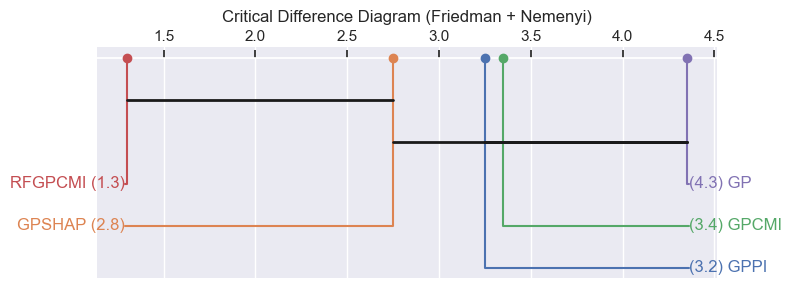

In [22]:
nemenyi_pvalues = sp.posthoc_nemenyi_friedman(median_test_loss_df.values)
nemenyi_pvalues.columns = order['method']
nemenyi_pvalues.index = order['method']

plt.figure(figsize=(8, 3))
sp.critical_difference_diagram(avg_ranks, nemenyi_pvalues, hue=hue, alpha=0.05)
plt.title("Critical Difference Diagram (Friedman + Nemenyi)")
plt.show()